In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UNSW_NB15_training-set.csv to UNSW_NB15_training-set.csv


In [ ]:
import pandas as pd #data preprocessing o handle diverse data types (numerical, textual, categorical, datetime) within a structured, labeled format.
import numpy as np #data preprocessing of homogeneous numerical data.
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


#Load and select important feature


In [ ]:
#load dataset
import io
df=pd.read_csv(io.BytesIO(uploaded['UNSW_NB15_training-set.csv']))
# Select only the most relevant features for NIDS
selected_columns = [
    "dur", "proto", "service", "state", "sbytes", "dbytes",
    "sttl", "dttl", "sload", "dload", "spkts", "dpkts",
    "ct_state_ttl", "label"
]
df = df[selected_columns]

#Preprocess the data


Encode Categorical Columns

In [ ]:
categorical_cols = ['proto', 'service', 'state']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
print(df.head())

        dur  proto  service  state  sbytes  dbytes  sttl  dttl         sload  \
0  0.121478    113        0      2     258     172   252   254  14158.942380   
1  0.649902    113        0      2     734   42014    62   252   8395.112305   
2  1.623129    113        0      2     364   13186    62   252   1572.271851   
3  1.681642    113        3      2     628     770    62   252   2740.178955   
4  0.449454    113        0      2     534     268   254   252   8561.499023   

           dload  spkts  dpkts  ct_state_ttl  label  
0    8495.365234      6      4             0      0  
1  503571.312500     14     38             1      0  
2   60929.230470      8     16             1      0  
3    3358.622070     12     12             1      0  
4    3987.059814     10      6             1      0  


 Normalize the Numerical Features



In [ ]:
X = df.drop('label', axis=1)
y = df['label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


#Split Data into Train and Test Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42)


Train the Model (Random Forest)

In [ ]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

Evaluate the Model

In [ ]:
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9448700644449937

Confusion Matrix:
 [[15053  1719]
 [ 1181 34650]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.91     16772
           1       0.95      0.97      0.96     35831

    accuracy                           0.94     52603
   macro avg       0.94      0.93      0.94     52603
weighted avg       0.94      0.94      0.94     52603



Save the Model and Preprocessors

In [ ]:
import joblib

joblib.dump(clf, 'rf_ids_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

for col, le in label_encoders.items():
    joblib.dump(le, f'{col}_encoder.pkl')


Accuracy: 0.8133186320171854
[[   91     0    50   399     6     0    52     0     0     0]
 [    2    69    58   386     3     0     6     3     1     1]
 [    7     2   538  2886    49     6    46    23    11     0]
 [   20     1   659  8886   160    11   178   214    22     7]
 [    4     3    66   511  3726     3   988    10    69     2]
 [    0     0    35   173    27 11830     7     1     1     1]
 [   35     1    14   155  1319     8 15185    20    35     0]
 [    0     2    94   679     2     0     8  2328     2     0]
 [    0     1     6    20   138     1    84     3   115     0]
 [    0     0     1    17     3     0     2     0     0    15]]
                precision    recall  f1-score   support

      Analysis       0.57      0.15      0.24       598
      Backdoor       0.87      0.13      0.23       529
           DoS       0.35      0.15      0.21      3568
      Exploits       0.63      0.87      0.73     10158
       Fuzzers       0.69      0.69      0.69      5382
   

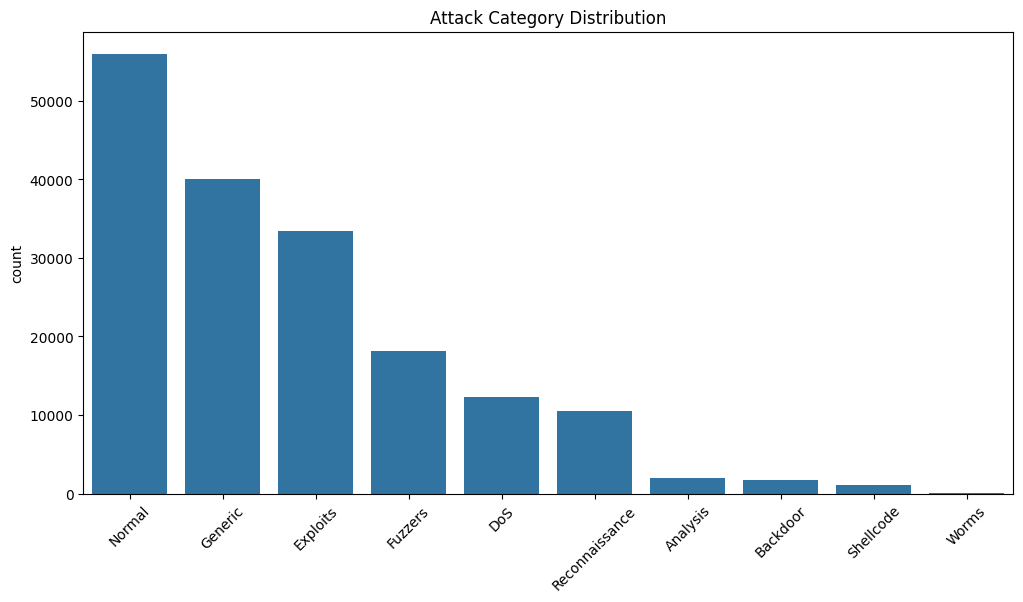

In [ ]:
# UNSW-NB15 IDS Full Project (Multi-class Classification + Streamlit + Scapy + Visualization)

# ---------- SECTION 1: IMPORT LIBRARIES ----------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# ---------- SECTION 2: LOAD & PREPROCESS DATA ----------
# Load CSV (update path as needed)
df = pd.read_csv('/content/UNSW_NB15_training-set.csv')

# Select meaningful features
selected_columns = [
    "dur", "proto", "service", "state", "sbytes", "dbytes",
    "sttl", "dttl", "sload", "dload", "spkts", "dpkts",
    "ct_state_ttl", "attack_cat"
]
df = df[selected_columns]

# Fill missing attack categories with 'Normal'
df['attack_cat'] = df['attack_cat'].fillna('Normal')

# Encode categorical features
cat_cols = ['proto', 'service', 'state']
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# Encode attack categories
le_attack = LabelEncoder()
df['attack_cat'] = le_attack.fit_transform(df['attack_cat'])

# Save encoders
joblib.dump(le_attack, 'attack_cat_encoder.pkl')
for col in cat_cols:
    joblib.dump(label_encoders[col], f'{col}_encoder.pkl')

# Split and scale
X = df.drop('attack_cat', axis=1)
y = df['attack_cat']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, 'scaler.pkl')

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# ---------- SECTION 3: MODEL TRAINING & EVALUATION ----------
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Save model
joblib.dump(clf, 'rf_ids_model.pkl')

# Evaluate
y_pred = clf.predict(X_test)
y_test_labels = le_attack.inverse_transform(y_test)
y_pred_labels = le_attack.inverse_transform(y_pred)

print("Accuracy:", accuracy_score(y_test_labels, y_pred_labels))
print(confusion_matrix(y_test_labels, y_pred_labels))
print(classification_report(y_test_labels, y_pred_labels))

# ---------- SECTION 4: VISUALIZATION ----------
plt.figure(figsize=(12,6))
sns.countplot(x=le_attack.inverse_transform(y), order=pd.Series(le_attack.inverse_transform(y)).value_counts().index)
plt.title("Attack Category Distribution")
plt.xticks(rotation=45)
plt.show()

#---------- SECTION 5: STREAMLIT APP (Save as ids_app.py) ----------
# import streamlit as st
# model = joblib.load('rf_ids_model.pkl')
# scaler = joblib.load('scaler.pkl')
# proto_enc = joblib.load('proto_encoder.pkl')
# service_enc = joblib.load('service_encoder.pkl')
# state_enc = joblib.load('state_encoder.pkl')
# attack_enc = joblib.load('attack_cat_encoder.pkl')

# st.title("Intrusion Detection System")
# uploaded_file = st.file_uploader("Upload CSV", type="csv")
# if uploaded_file is not None:
#     df_input = pd.read_csv(uploaded_file)
#     df_input = df_input[["dur", "proto", "service", "state", "sbytes", "dbytes",
#                          "sttl", "dttl", "sload", "dload", "spkts", "dpkts", "ct_state_ttl"]]
#     df_input['proto'] = proto_enc.transform(df_input['proto'].astype(str))
#     df_input['service'] = service_enc.transform(df_input['service'].astype(str))
#     df_input['state'] = state_enc.transform(df_input['state'].astype(str))
#     X_input = scaler.transform(df_input)
#     pred = model.predict(X_input)
#     df_input['Predicted Category'] = attack_enc.inverse_transform(pred)
#     st.write(df_input)

# ---------- SECTION 6: SCAPY LIVE PREDICTION (Example Only) ----------
# from scapy.all import sniff, IP
# def extract_features(pkt):
#     if not IP in pkt:
#         return None
#     proto = pkt.proto
#     proto_name = {6: 'tcp', 17: 'udp', 1: 'icmp'}.get(proto, 'other')
#     features = {
#         'dur': 0, 'proto': proto_enc.transform([proto_name])[0], 'service': 0, 'state': 0,
#         'sbytes': len(pkt), 'dbytes': 0, 'sttl': pkt[IP].ttl, 'dttl': pkt[IP].ttl,
#         'sload': 0, 'dload': 0, 'spkts': 1, 'dpkts': 0, 'ct_state_ttl': 1
#     }
#     return pd.DataFrame([features])

# def predict_packet(pkt):
#     feat = extract_features(pkt)
#     if feat is not None:
#         scaled = scaler.transform(feat)
#         pred = model.predict(scaled)
#         print("Predicted Attack:", attack_enc.inverse_transform(pred))

# sniff(prn=predict_packet, count=10)


In [ ]:
pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.4 MB/s eta 0:00:00


#---------- SECTION 5: STREAMLIT APP (Save as ids_app.py) ----------

In [ ]:
 import streamlit as st
 model = joblib.load('rf_ids_model.pkl')
 scaler = joblib.load('scaler.pkl')
 proto_enc = joblib.load('proto_encoder.pkl')
 service_enc = joblib.load('service_encoder.pkl')
 state_enc = joblib.load('state_encoder.pkl')
 attack_enc = joblib.load('attack_cat_encoder.pkl')

 st.title("Intrusion Detection System")
 uploaded_file = st.file_uploader("Upload CSV", type="csv")
 if uploaded_file is not None:
     df_input = pd.read_csv(uploaded_file)
     df_input = df_input[["dur", "proto", "service", "state", "sbytes", "dbytes",
                          "sttl", "dttl", "sload", "dload", "spkts", "dpkts", "ct_state_ttl"]]
     df_input['proto'] = proto_enc.transform(df_input['proto'].astype(str))
     df_input['service'] = service_enc.transform(df_input['service'].astype(str))
     df_input['state'] = state_enc.transform(df_input['state'].astype(str))
     X_input = scaler.transform(df_input)
     pred = model.predict(X_input)
     df_input['Predicted Category'] = attack_enc.inverse_transform(pred)
     st.write(df_input)

# ---------- SECTION 6: SCAPY LIVE PREDICTION (Example Only) ----------
# from scapy.all import sniff, IP
# def extract_features(pkt):
#     if not IP in pkt:
#         return None
#     proto = pkt.proto
#     proto_name = {6: 'tcp', 17: 'udp', 1: 'icmp'}.get(proto, 'other')
#     features = {
#         'dur': 0, 'proto': proto_enc.transform([proto_name])[0], 'service': 0, 'state': 0,
#         'sbytes': len(pkt), 'dbytes': 0, 'sttl': pkt[IP].ttl, 'dttl': pkt[IP].ttl,
#         'sload': 0, 'dload': 0, 'spkts': 1, 'dpkts': 0, 'ct_state_ttl': 1
#     }
#     return pd.DataFrame([features])

# def predict_packet(pkt):
#     feat = extract_features(pkt)
#     if feat is not None:
#         scaled = scaler.transform(feat)
#         pred = model.predict(scaled)
#         print("Predicted Attack:", attack_enc.inverse_transform(pred))

# sniff(prn=predict_packet, count=10)

2025-07-21 16:39:44.680 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-21 16:39:44.919 
  command:

    streamlit run /usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-07-21 16:39:44.919 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-21 16:39:44.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-21 16:39:44.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-21 16:39:44.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-21 16:39:44.923 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-07-21 16:39:44.925 Thread 'MainThread': mi

In [ ]:
pip install scapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 60.0 MB/s eta 0:00:00


In [ ]:
import scapy

In [ ]:
from scapy.all import sniff, IP
import pandas as pd
import joblib
import time

# Load your model and preprocessors
model = joblib.load('rf_ids_model.pkl')
scaler = joblib.load('scaler.pkl')
proto_enc = joblib.load('proto_encoder.pkl')
attack_enc = joblib.load('attack_cat_encoder.pkl')

# Define feature extraction function
def extract_features(pkt):
    if not IP in pkt:
        return None

    ip = pkt[IP]
    proto_num = ip.proto
    proto_name = {6: 'tcp', 17: 'udp', 1: 'icmp'}.get(proto_num, 'other')

    try:
        proto_enc_value = proto_enc.transform([proto_name])[0]
    except:
        proto_enc_value = 0  # Fallback if unseen protocol

    features = {
        'dur': 0,
        'proto': proto_enc_value,
        'service': 0,  # You can enhance this if needed
        'state': 0,    # Likewise
        'sbytes': len(pkt),
        'dbytes': 0,
        'sttl': ip.ttl,
        'dttl': ip.ttl,
        'sload': 0,
        'dload': 0,
        'spkts': 1,
        'dpkts': 0,
        'ct_state_ttl': 1
    }
    return pd.DataFrame([features])

# Define prediction callback
def predict_packet(pkt):
    try:
        features_df = extract_features(pkt)
        if features_df is not None:
            scaled = scaler.transform(features_df)
            pred = model.predict(scaled)
            label = attack_enc.inverse_transform(pred)[0]
            print(f"[{time.strftime('%H:%M:%S')}] Detected: {label}")
    except Exception as e:
        print("Error during prediction:", e)

print("🔴 Starting live IDS... Press CTRL+C to stop.")
# Start sniffing continuously
sniff(prn=predict_packet, store=False)


Streaming output truncated to the last 5000 lines.
[17:18:54] Detected: Normal
[17:18:54] Detected: Normal
[17:18:55] Detected: Normal
[17:18:55] Detected: Normal
[17:18:55] Detected: Normal
[17:18:55] Detected: Normal
[17:18:55] Detected: Normal
[17:18:55] Detected: Normal
[17:18:55] Detected: Normal
[17:18:55] Detected: Normal
[17:18:55] Detected: Normal
[17:18:55] Detected: Normal
[17:18:56] Detected: Normal
[17:18:56] Detected: Normal
[17:18:56] Detected: Normal
[17:18:56] Detected: Normal
[17:18:56] Detected: Normal
[17:18:56] Detected: Normal
[17:18:56] Detected: Normal
[17:18:56] Detected: Normal
[17:18:56] Detected: Normal
[17:18:56] Detected: Normal
[17:18:57] Detected: Normal
[17:18:57] Detected: Normal
[17:18:57] Detected: Normal
[17:18:57] Detected: Normal
[17:18:57] Detected: Normal
[17:18:57] Detected: Normal
[17:18:57] Detected: Normal
[17:18:57] Detected: Normal
[17:18:57] Detected: Normal
[17:18:57] Detected: Normal
[17:18:57] Detected: Normal
[17:18:57] Detected: Norm

In [ ]:
print("XGBoost Accuracy: {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))
print(classification_report(y_test, y_pred))